In [28]:
from torch import nn, optim, as_tensor
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torch.optim import lr_scheduler
from torch.nn.init import *
from torchvision import transforms, utils, datasets, models
#from models.inception_resnet_v1 import InceptionResnetV1
from mtcnn.mtcnn import MTCNN
import cv2
from PIL import Image
from pdb import set_trace
import time
import copy
from pathlib import Path
import os
import sys
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from skimage import io, transform
from tqdm import trange, tqdm
import csv
import glob
import dlib
import pandas as pd
import numpy as np

preprocessing

img before preprocessing

In [44]:
img_path= r'E:\Hari\sem6\minor project\minor project proposal\BCTMinorProject\CODE\data\preprocessme\train\Hari Krishna Khuju\face_1_20230208_124848.jpg'
image = cv2.imread(img_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_rgb.shape

(650, 472, 3)

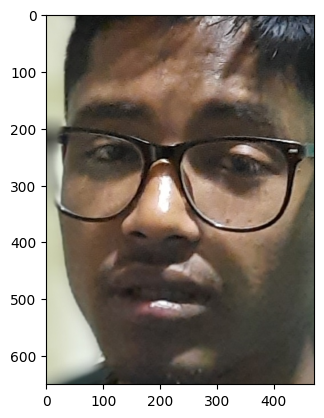

In [38]:
plt.imshow(image_rgb)

image after preprocessing

In [54]:
def preprocess_data(input_dir, output_dir, target_size=(160, 160)):
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    for sub_dir in os.listdir(input_dir):
        sub_dir_path = os.path.join(input_dir, sub_dir)
        output_sub_dir = os.path.join(output_dir, sub_dir)
        os.makedirs(output_sub_dir, exist_ok=True)

        for file_name in tqdm(os.listdir(sub_dir_path), desc=f"Processing {sub_dir}"):
            file_path = os.path.join(sub_dir_path, file_name)

            if file_name.endswith((".jpg", ".jpeg", ".png")):
                img = cv2.imread(file_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                # Resize image to the target size
                img = cv2.resize(img, target_size)

                # Normalize pixel values to the range [0, 1]
                img = img / 255.0

                # Save the preprocessed image
                output_file_path = os.path.join(output_sub_dir, file_name)
                cv2.imwrite(output_file_path, img)

if __name__ == "__main__":
    input_directory = r'E:\Hari\sem6\minor project\minor project proposal\BCTMinorProject\CODE\data\preprocessme\train'  # Update with your input directory
    output_directory = r'E:\Hari\sem6\minor project\minor project proposal\BCTMinorProject\CODE\data\test_me\train'
    preprocess_data(input_directory, output_directory)

Processing Hari Krishna Khuju: 100%|██████████| 5/5 [00:00<00:00, 21.28it/s]


In [49]:
img_path= r'E:\Hari\sem6\minor project\minor project proposal\BCTMinorProject\CODE\data\test_me\train\Hari Krishna Khuju\face_1_20230208_124848.jpg'
image = cv2.imread(img_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_rgb.shape

error: OpenCV(4.9.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:196: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


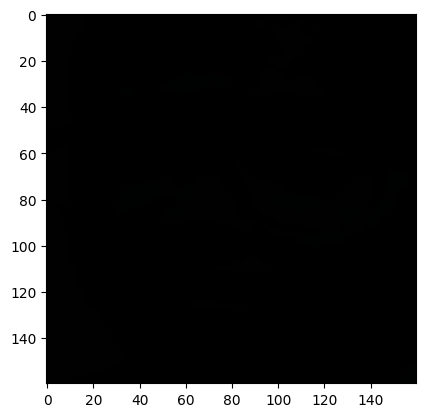

In [46]:
plt.imshow(image_rgb)